<a href="https://colab.research.google.com/github/FRIDA-34/EstadisticaVerano2026/blob/main/GymMembers/v017_u1_06_24150720.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/FRIDA-34/EstadisticaVerano2026/refs/heads/main/StudentPerformance/gym_members_exercise_tracking%20(1).csv")
df

,Age,Gender,Weight_(kg),Height_(m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration_(hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74


Establecemos las calorias quemadas (Calories_Burned) como la variable dependiente y la duración de sesión (Session duration "hours") como la variable independiente. Esto porque el enunciado nos menciona que dependiendo de la duración de la sesión nos daria como resultado la cantidad de calorias quemadas.

In [ ]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/FRIDA-34/EstadisticaVerano2026/refs/heads/main/StudentPerformance/gym_members_exercise_tracking%20(1).csv")
X = df["Session_Duration_(hours)"] # Variable independiente
Y = df["Calories_Burned"] # Variable dependiente

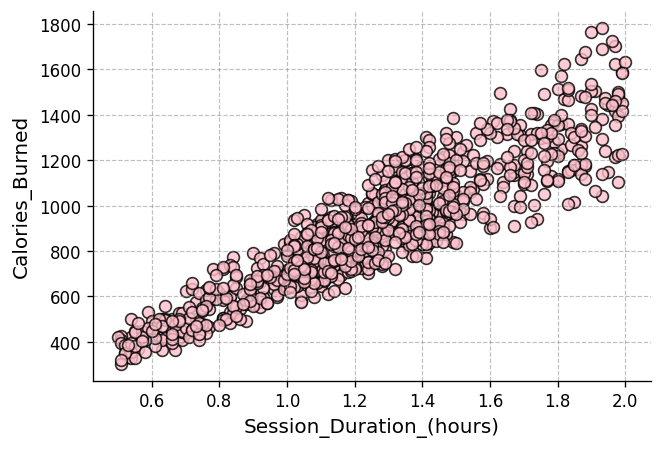

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='pink',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Session_Duration_(hours)', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Calories_Burned', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)


El gráfico de disperión nos muestra una linealidad ya que se agrupan alrededor de una línea recta, al igual muestra que entre más tiempo dure la sesión de entrenamiento aumentaran las calorias quemadas. Con esto se espera que tenga como resultado una correlación positica fuerte.

In [ ]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')



Coeficiente de correlación:  0.9081
valor_p:  0.0000


El coeficiente de corelación $r=0.9081$ nos indica una correlación lineal fuerte y positiva, entre la duración de la sesión y las calorías quemadas.

In [ ]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo=sm.OLS(Y,x_constante).fit()
y_calculada =modelo.predict(x_constante)


In [ ]:
#Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, y_calculada)
print(f"Coeficiente de determinación:{r2: 0.2f}")


Coeficiente de determinación: 0.82


El modelo de regresión lineal presenta un coeficiente de determinación $r^2=82.47%$ esto nos quiere decir que la variabilidad de calorias quemadas se pueden definir por la duración del entrenamiento. El restante se debe a factores externos.

In [ ]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo=sm.OLS(Y,x_constante).fit()
y_calculada =modelo.predict(x_constante)

modelo.params

,0
const,-1.446459
Session_Duration_(hours),721.786016


La ecuación de la recta es:
$$
\hat{y}=-1.446459+721.786016x
$$

La pendiente $b_1=721.786016$ indica que existe una relación positiva entre las variables.

Y el intercepto $b_0=-1.4465$ representa el valor estimado de calorías quemadas si la duración del entrenamiento fuera de cero horas.

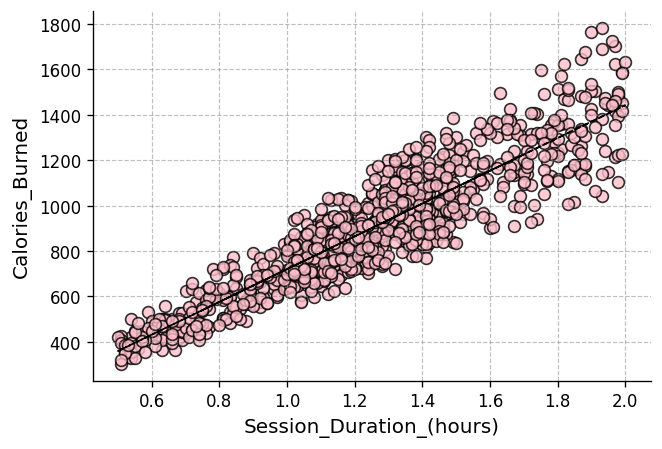

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)


# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='pink',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

 #Gráfico de línea
plt.plot(
    X,y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Session_Duration_(hours)', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Calories_Burned', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)


La recta de regresión obtenida muestra una relación positiva fuerte. Esto ayuda a reconocer que el tiempo de duración de la sesión si nos permite conocer las calorías quemadas.

In [ ]:
_1# intervalo de confianza
modelo.conf_int(alpha=0.05)

,0,1
const,-28.738459,25.845542
Session_Duration_(hours),700.830270,742.741762


Obtuvimos un resultado que dio entre $700.83$ y $742.74$ con un 95% de confianza, esto quiere decir que con un ritmo no tan activo nuestro límite mínimo es de $700.83$ calorías quemadas y con un ritmo más intenso nuestro límite es de $742.74$ calorías quemadas.

In [ ]:
residuales = modelo.resid

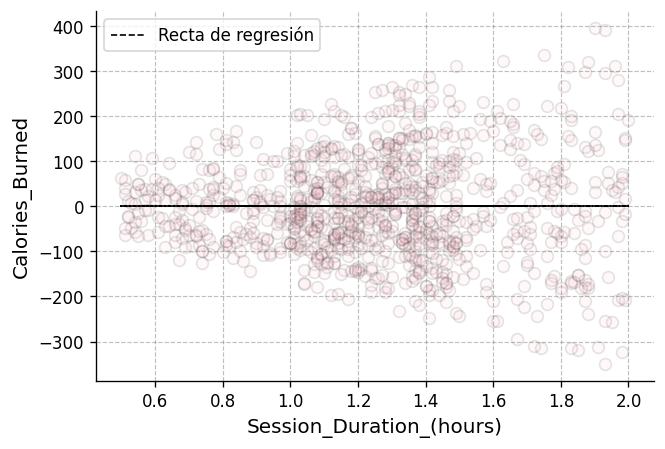

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, residuales,      #
    marker="o",       # forma: googlear "matplotlib.markers"
    color='pink',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.1,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada * 0,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Session_Duration_(hours)', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Calories_Burned', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    fontsize=10,
    loc='best'
)


valor-p (Shapiro) = 0.003841645423152361


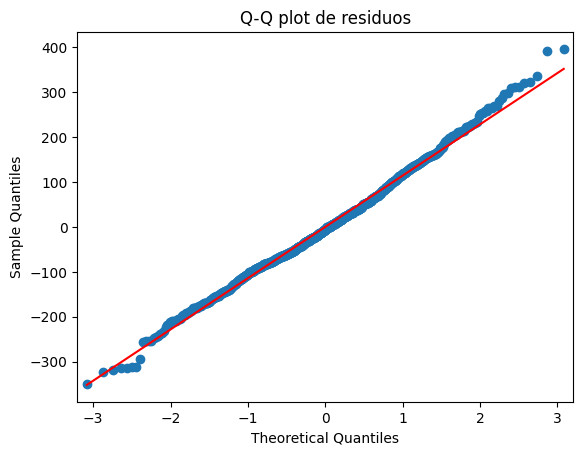

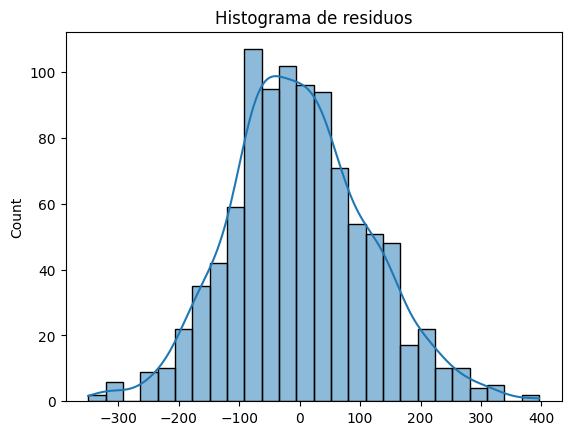

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# n < 30, Shapiro es el mas confiable
# n > 30, Histograma o Q-Q plot


#test de Shapiro-Wilk
1
#H0: Hay normalidad  0.0.4172971767713699
#H1: No hay normalidad


# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()


In [ ]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
x_constante = sm.add_constant(X)
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.0000



In [ ]:
from statsmodels.formula.api import ols
# y ~ x
modelo_lineal=ols("Calories_Burned~Q('Session_Duration_(hours)')", data=df).fit()
tabla_anova=sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
Q('Session_Duration_(hours)'),1.0,5.958764e+07,5.958764e+07,4568.674447,0.0
Residual,971.0,1.266442e+07,1.304265e+04,NaN,NaN
